In [1]:
    from nrem_analysis.constant import PROCESSED_DIR, FIGURES_DIR, INTERIM_DIR
    from pathlib import Path

    import pynapple as nap
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats

    from cmap import Colormap

    cm = Colormap("colorbrewer:Set2")

    plt.rcParams.update({
        "figure.dpi":        150,
        "savefig.dpi":       320,
        "font.family":       "sans-serif",
        'font.sans-serif':   "Arial",
        "axes.grid":         False,
        "figure.constrained_layout.use": True,
    })

    def circdiff(x, y):
        return (x - y + 180) % 360 - 180

    STATE_NAMES = ["continuous", "fragmented", "stationary"]
    MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

### Visualize STA

In [2]:
def plot_sta(sta_awake, sta_nrem, sc_units, turn_units, ncols=4, figsize=None):
    n_units = sta_awake.shape[1]
    nrows = int(np.ceil(n_units / ncols))

    if figsize is None:
        width = max(4.0, ncols * 3.0)
        height = max(3.0, nrows * 2.5)
        figsize = (width, height)

    f, axs = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axs = np.array(axs).flatten()

    zero_idx = np.where(sta_awake.index == 0)[0].item()
    sta_awake_norm = circdiff(sta_awake, sta_awake[zero_idx, :])

    zero_idx = np.where(sta_nrem.index == 0)[0].item()
    sta_nrem_norm = circdiff(sta_nrem, sta_nrem[zero_idx, :])

    for i, uid in enumerate(sc_units):
        ax1 = axs[i]
        if uid in turn_units.keys():
            ax1.set_title(f"Unit: {uid} (TSI: {turn_units['turn_index'][uid]:.2f})", fontsize=16, color='tab:green')
        else:
            ax1.set_title(f"Unit: {uid}", fontsize=16)

        color = 'tab:blue'
        ax1.plot(sta_awake_norm[:, i], color=color)
        ax1.tick_params(axis='x', labelcolor=color)

        ax2 = ax1.twiny()
        color = 'tab:red'
        ax2.plot(sta_nrem_norm[:, i], color=color)
        ax2.tick_params(axis='x', labelcolor=color)

        ax1.axvline(0, color='k', linestyle='--', linewidth=0.5)
        ax1.axhline(0, color='k', linestyle='--', linewidth=0.5)

    for ax in axs[n_units:]:
        ax.set_visible(False)

    f.legend(["Awake", "NREM"], loc='upper left')
    return f, axs[:n_units]

In [3]:
save_dir = FIGURES_DIR / "sta" / "mv2st99"
save_dir.mkdir(exist_ok=True)

tsi              = []
sta_awakes       = []
sta_nrems        = []
sta_nrem_conts   = []

for mouse_id in MOUSE_IDS:
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    sc_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sc_units.npz")
    sta_awake       = nap.load_file(INTERIM_DIR / "mv2st99" / mouse_id / "sta_awake_sc.npz")
    sta_nrem_cont   = nap.load_file(INTERIM_DIR / "mv2st99"  / mouse_id /"sta_nrem_cont_sc.npz")
    sta_nrem        = nap.load_file(INTERIM_DIR / "mv2st99" / mouse_id / "sta_nrem_sc.npz")
 
    idx = np.searchsorted(sc_units.keys(), turn_units.keys())

    tsi.append(turn_units['turn_index'].values)
    sta_awakes.append(sta_awake[:, idx])
    sta_nrems.append(sta_nrem[:, idx])
    sta_nrem_conts.append(sta_nrem_cont[:, idx])

    f, ax = plot_sta(sta_awake, sta_nrem, sc_units, turn_units)
    f.suptitle(f"{mouse_id} (all NREM epochs)", fontsize=20)
    plt.savefig(save_dir / f"sta_{mouse_id}.png")
    plt.close(f)

    f, ax = plot_sta(sta_awake, sta_nrem_cont, sc_units, turn_units)
    f.suptitle(f"{mouse_id} (Continuous NREM epochs)", fontsize=20)
    plt.savefig(save_dir / f"sta_{mouse_id}_cont.png")
    plt.close(f)

sta_awake       = np.column_stack(sta_awakes)
sta_nrem        = np.column_stack(sta_nrems)
sta_nrem_cont   = np.column_stack(sta_nrem_conts)
tsi             = np.concatenate(tsi)
order           = np.argsort(tsi)

In [12]:
tsi_all          = []
sta_awakes       = []
sta_nrems        = []
sta_nrem_conts   = []

for mouse_id in MOUSE_IDS:
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    sc_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sc_units.npz")

    idx = np.searchsorted(sc_units.keys(), turn_units.keys())
    tsi_all.append(turn_units['turn_index'].values)

    for sta_path, container in zip(["sta_awake_sc.npz", "sta_nrem_sc.npz", "sta_nrem_cont_sc.npz"], [sta_awakes, sta_nrems, sta_nrem_conts]):
        sta = nap.load_file(INTERIM_DIR / "mv2st99" / mouse_id / sta_path)
        zero_idx = np.where(sta.index == 0)[0].item()
        baseline = sta[zero_idx, :]
        sta_norm = circdiff(sta, baseline)
        container.append(sta_norm[:, idx]) 

tsi_all         = np.concatenate(tsi_all)
sta_awake       = np.column_stack(sta_awakes)
sta_nrem        = np.column_stack(sta_nrems)
sta_nrem_cont   = np.column_stack(sta_nrem_conts)
order = np.argsort(tsi_all)

In [6]:
turn_cell_ids = ~np.isnan(tsi_all)
tsi = tsi_all[turn_cell_ids]
sta_awake = sta_awake[:, turn_cell_ids]
sta_nrem = sta_nrem[:, turn_cell_ids]
sta_nrem_cont = sta_nrem_cont[:, turn_cell_ids]
order = np.argsort(tsi)

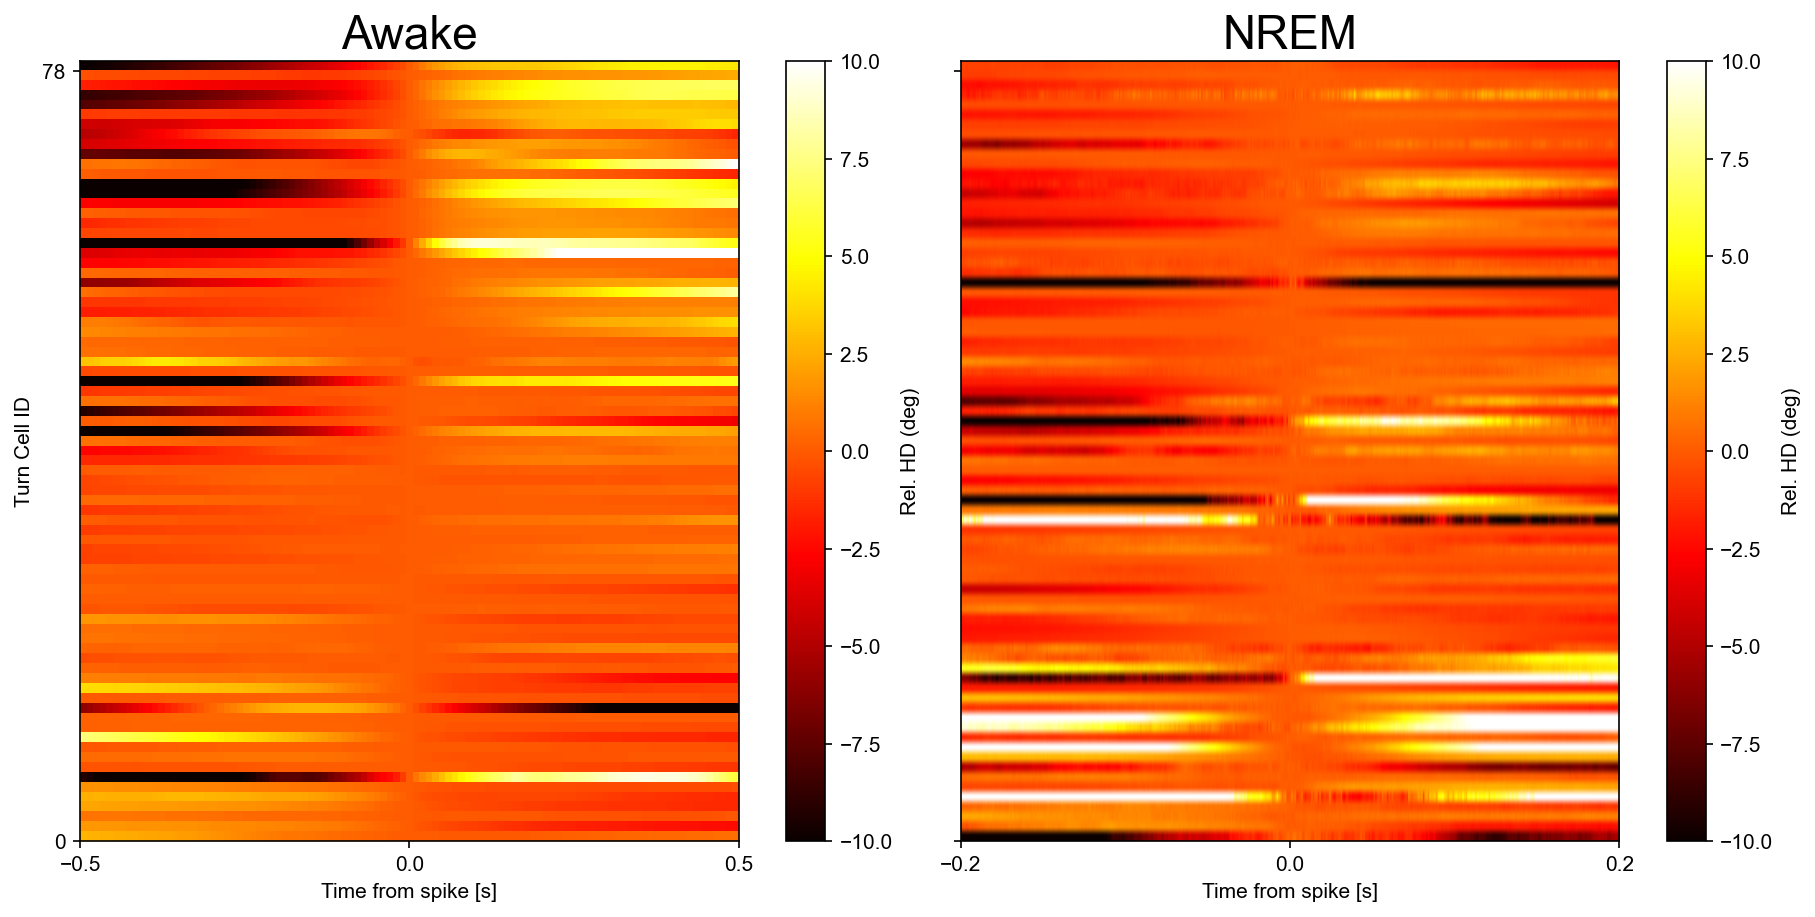

In [ ]:
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem], ["Awake", "NREM"])):
    im = axes[i].imshow(sta_norm.d.T, aspect='auto', origin='lower',
                        extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]],
                        cmap='hot',
                        norm=norm,
                        )
    
    plt.colorbar(im, ax=axes[i], label='Rel. HD (deg)')
    axes[i].set_title(f"{state}", fontsize=22)
    axes[i].set_xlabel("Time from spike [s]")
    
axes[0].set_ylabel("Turn Cell ID")
axes[0].set_yticks([0, sta_norm.shape[1]-1])
axes[0].set_xticks([-0.5, 0, 0.5])
axes[1].set_xticks([-0.2, 0, 0.2])
plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_turn.png")

In [21]:
tsi_all          = []
sta_awakes       = []
sta_nrems        = []
sta_nrem_conts   = []

for mouse_id in MOUSE_IDS:
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    sc_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sc_units.npz")
    tsi_all.append(turn_units['turn_index'].values)

    for sta_path, container in zip(["sta_awake_sc.npz", "sta_nrem_sc.npz", "sta_nrem_cont_sc.npz"], [sta_awakes, sta_nrems, sta_nrem_conts]):
        sta = nap.load_file(INTERIM_DIR / "mv2st99" / mouse_id / sta_path)
        zero_idx = np.where(sta.index == 0)[0].item()
        baseline = sta[zero_idx, :]
        sta_norm = circdiff(sta, baseline)
        container.append(sta_norm) 

tsi_all         = np.concatenate(tsi_all)
sta_awake       = np.column_stack(sta_awakes)
sta_nrem        = np.column_stack(sta_nrems)
sta_nrem_cont   = np.column_stack(sta_nrem_conts)
order = np.argsort(tsi_all)

IndexError: index 0 is out of bounds for axis 0 with size 0

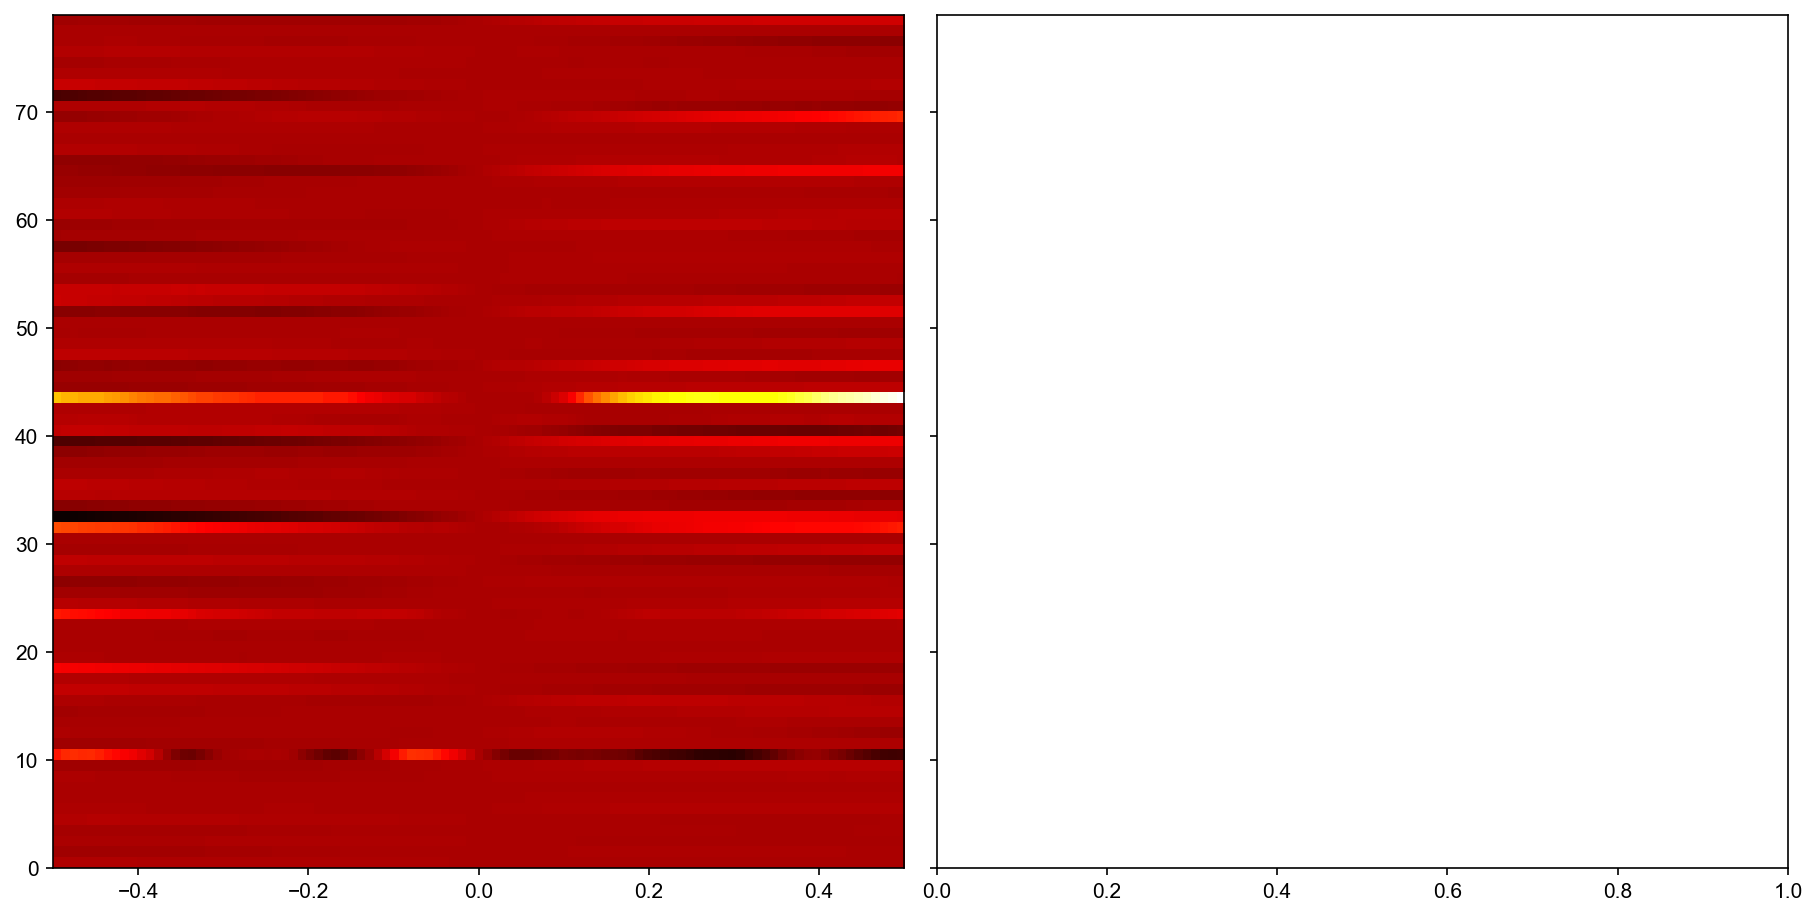

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem], ["Awake", "NREM"])):
    
    im = axes[i].imshow(sta_norm.d.T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
    
    nan_cutoff = np.where(np.isnan(tsi_all[order]))[0][0].item()
    axes[i].axhline(nan_cutoff, linewidth=0.6, c='k')

    plt.colorbar(im, ax=axes[i], label='Rel HD (deg)')
    axes[i].set_title(f"{state}", fontsize=22)
    axes[i].set_xlabel("Time from spike [s]")
    
axes[0].set_ylabel("Turn Cell ID")
axes[0].set_yticks([0, sta_norm.shape[1]-1])
plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_all.png")

In [8]:
def get_tsi_extremes(tsi_all, n=5):
    finite_idx = np.flatnonzero(np.isfinite(tsi_all))
    ranked_idx = finite_idx[np.argsort(tsi_all[finite_idx])]

    n = min(n, len(ranked_idx))
    low_idx = ranked_idx[:n]
    high_idx = ranked_idx[-n:][::-1]

    return low_idx, high_idx

def plot_sta_by_tsi(
    sta_awake,
    sta_nrem,
    tsi_all,
    selected_idx,
    unit_labels=None,
    title=None,
    ncols=5,
    figsize=None,
    nrem_label="NREM",
):
    selected_idx = np.asarray(selected_idx, dtype=int)
    n_units = len(selected_idx)
    nrows = int(np.ceil(n_units / ncols))

    if figsize is None:
        figsize = (ncols * 3.0, nrows * 2.5)

    f, axs = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axs = np.array(axs).flatten()

    awake_zero_idx = np.where(sta_awake.index == 0)[0].item()
    nrem_zero_idx = np.where(sta_nrem.index == 0)[0].item()

    sta_awake_sel = sta_awake[:, selected_idx]
    sta_nrem_sel = sta_nrem[:, selected_idx]

    sta_awake_norm = circdiff(sta_awake_sel, sta_awake[awake_zero_idx, selected_idx])
    sta_nrem_norm = circdiff(sta_nrem_sel, sta_nrem[nrem_zero_idx, selected_idx])

    for i, col_idx in enumerate(selected_idx):
        ax1 = axs[i]

        unit_label = f"col {col_idx}"
        if unit_labels is not None:
            unit_label = unit_labels[col_idx]

        ax1.set_title(
            f"{unit_label} (TSI: {tsi_all[col_idx]:.2f})",
            fontsize=11,
            color="tab:green",
        )

        line1, = ax1.plot(sta_awake.index, sta_awake_norm.d[:, i], color="tab:blue")
        ax1.tick_params(axis="x", labelcolor="tab:blue")
        ax1.axvline(0, color="k", linestyle="--", linewidth=0.5)
        ax1.axhline(0, color="k", linestyle="--", linewidth=0.5)
        ax1.axvline(0.2, color='tab:blue', linestyle='--', linewidth=0.5)
        ax1.axvline(-0.2, color='tab:blue', linestyle='--', linewidth=0.5)
        ax1.set_xticks([-0.5, -0.2, 0, 0.2, 0.5])
        ax1.set_xlabel("Time [s]")

        ax2 = ax1.twiny()
        
        line2, = ax2.plot(sta_nrem.index, sta_nrem_norm.d[:, i], color="tab:red")
        ax2.tick_params(axis="x", labelcolor="tab:red")
        ax2.axvline(0, color="k", linestyle="--", linewidth=0.5)

        ax1.axvline(0.05, color='tab:red', linestyle='--', linewidth=0.5)
        ax1.axvline(-0.05, color='tab:red', linestyle='--', linewidth=0.5)
        ax2.set_xticks([-0.2, 0, 0.2])

    axs[0].set_ylabel("Rel. HD [deg]")
    for ax in axs[n_units:]:
        ax.set_visible(False)

    if title is not None:
        f.suptitle(title, fontsize=16)

    f.legend(
        handles=[line1, line2],
        labels=["Awake", nrem_label],
        loc="upper left"
        )

    return f, axs[:n_units]

In [9]:
unit_labels = []

for mouse_id in MOUSE_IDS:
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    unit_labels.extend([f"{mouse_id}:{uid}" for uid in turn_units.keys()])

unit_labels = np.asarray(unit_labels)
assert len(unit_labels) == len(tsi) == sta_awake.shape[1]

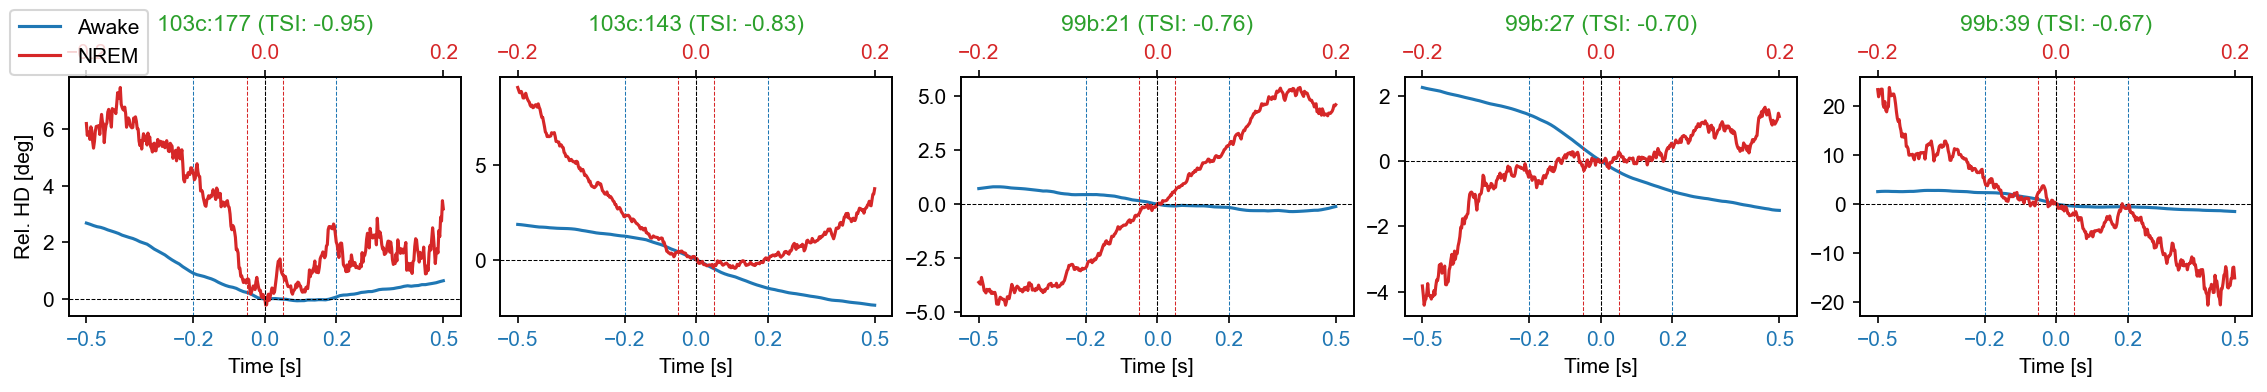

In [10]:
low5_idx, high5_idx = get_tsi_extremes(tsi, n=5)

f, ax = plot_sta_by_tsi(
    sta_awake,
    sta_nrem_cont,
    tsi,
    low5_idx,
    unit_labels=unit_labels,
)
plt.savefig(FIGURES_DIR / "sta"  / "mv2st99" / "sta_lowest5_tsi.png")

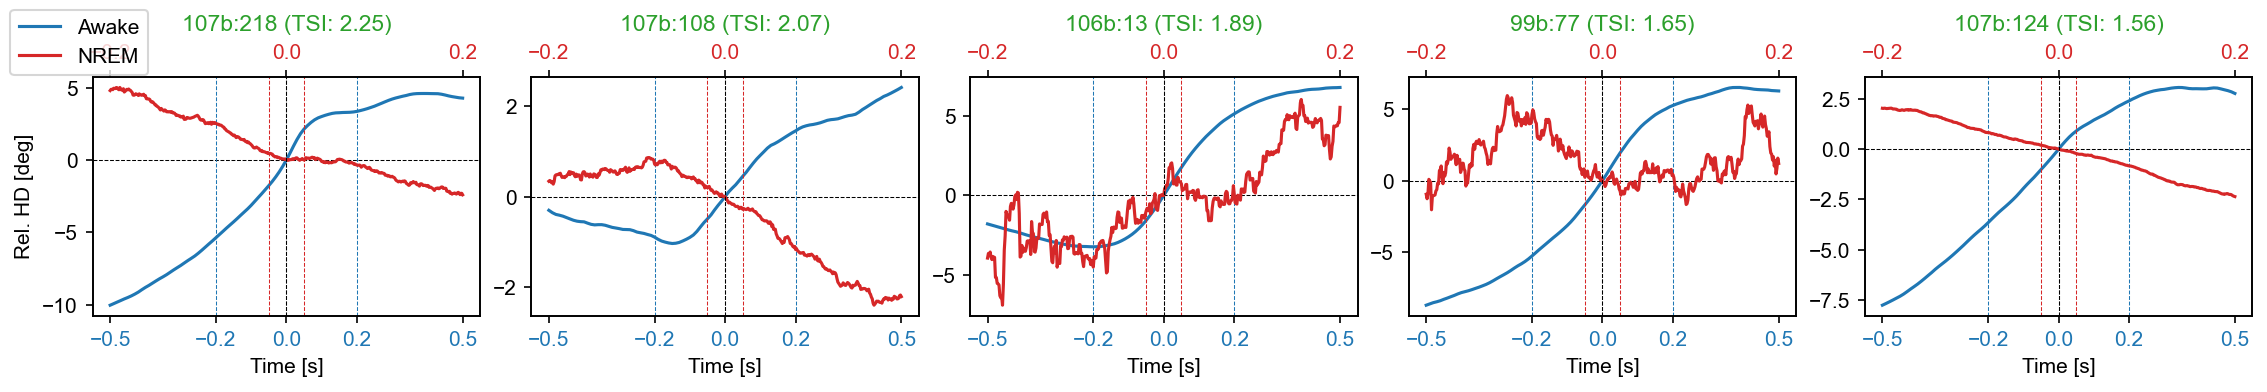

In [11]:
f, ax = plot_sta_by_tsi(
    sta_awake,
    sta_nrem_cont,
    tsi,
    high5_idx,
    unit_labels=unit_labels,
)
plt.savefig(FIGURES_DIR / "sta"/ "mv2st99" / "sta_top5_tsi.png")

### Turn amplitude

In [140]:
def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return circdiff(sta[after_idx, :], sta[before_idx, :])

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [129]:
turn_amps_awake = amplitude_at_threshold(sta_awake, sta_awake.t, 0.2)
turn_amps_nrem  = amplitude_at_threshold(sta_nrem, sta_nrem.t, 0.05)
turn_amps_nrem_cont  = amplitude_at_threshold(sta_nrem_cont, sta_nrem_cont.t, 0.05)

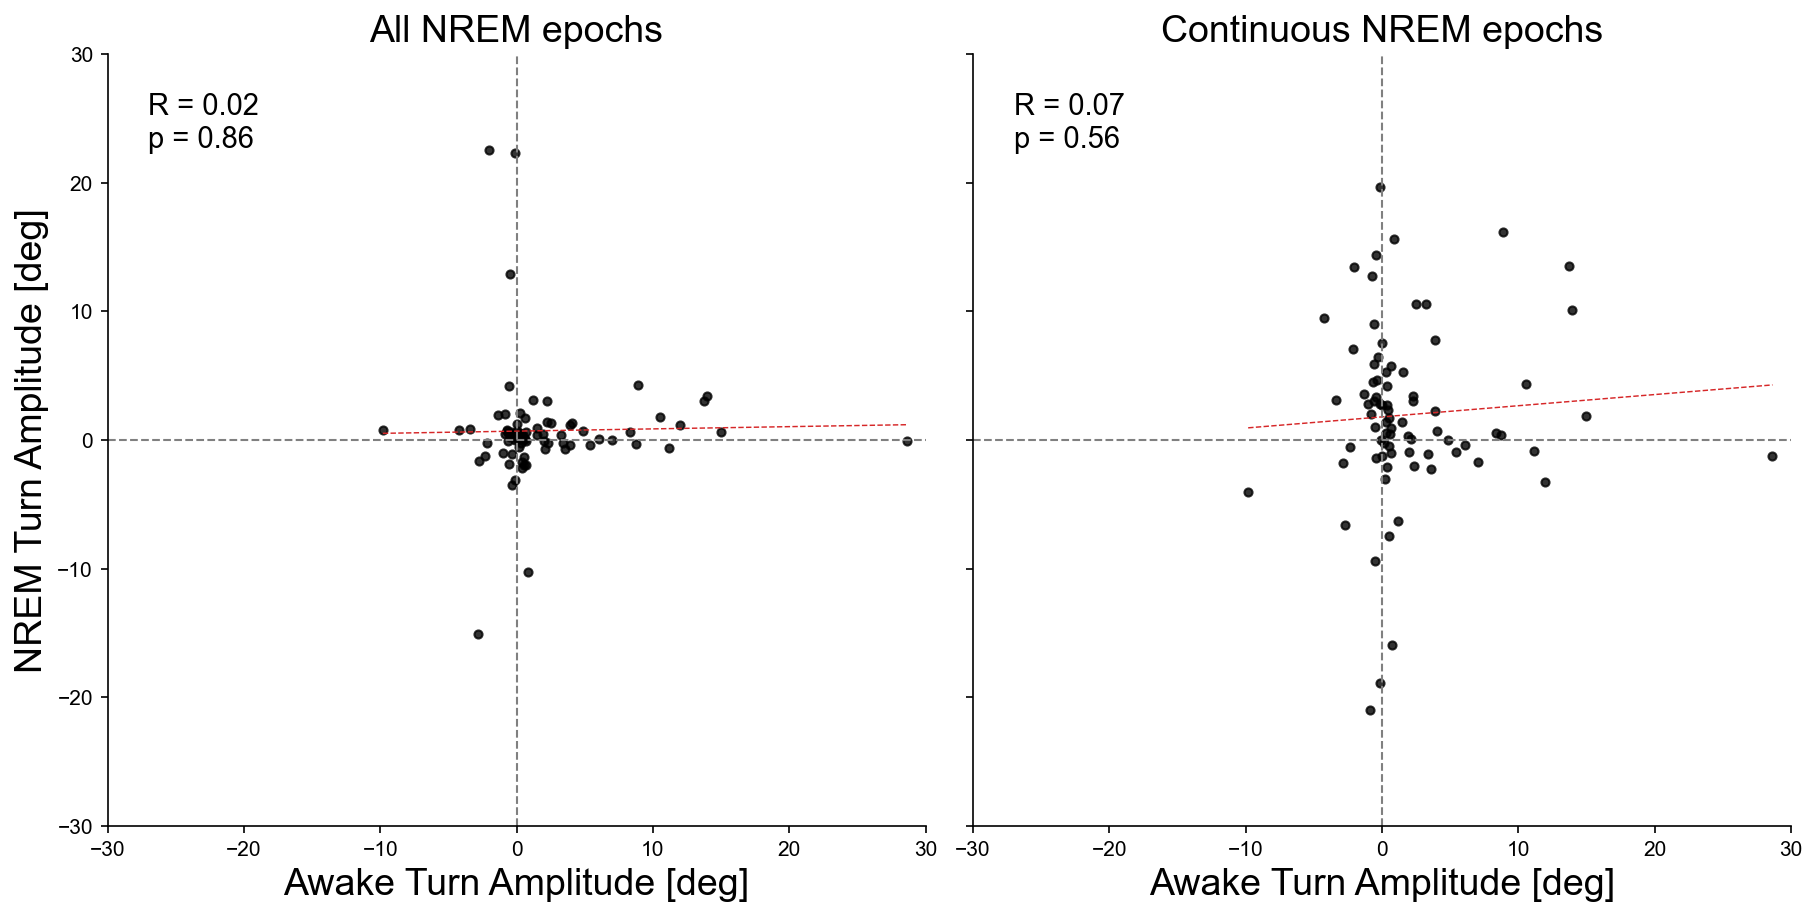

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True)

save_dir = FIGURES_DIR / "turn_amplitude"
save_dir.mkdir(exist_ok=True)

plot_scatter_with_regression(axes[0], turn_amps_awake, turn_amps_nrem, "All NREM epochs", xlabel='Awake Turn Amplitude [deg]', ylabel='NREM Turn Amplitude [deg]')
plot_scatter_with_regression(axes[1], turn_amps_awake, turn_amps_nrem_cont, "Continuous NREM epochs", xlabel='Awake Turn Amplitude [deg]')

for ax in axes:
    ax.set_xlim((-30, 30))
    ax.set_ylim((-30, 30))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig(save_dir / "turn_amplitude_across_states.png")

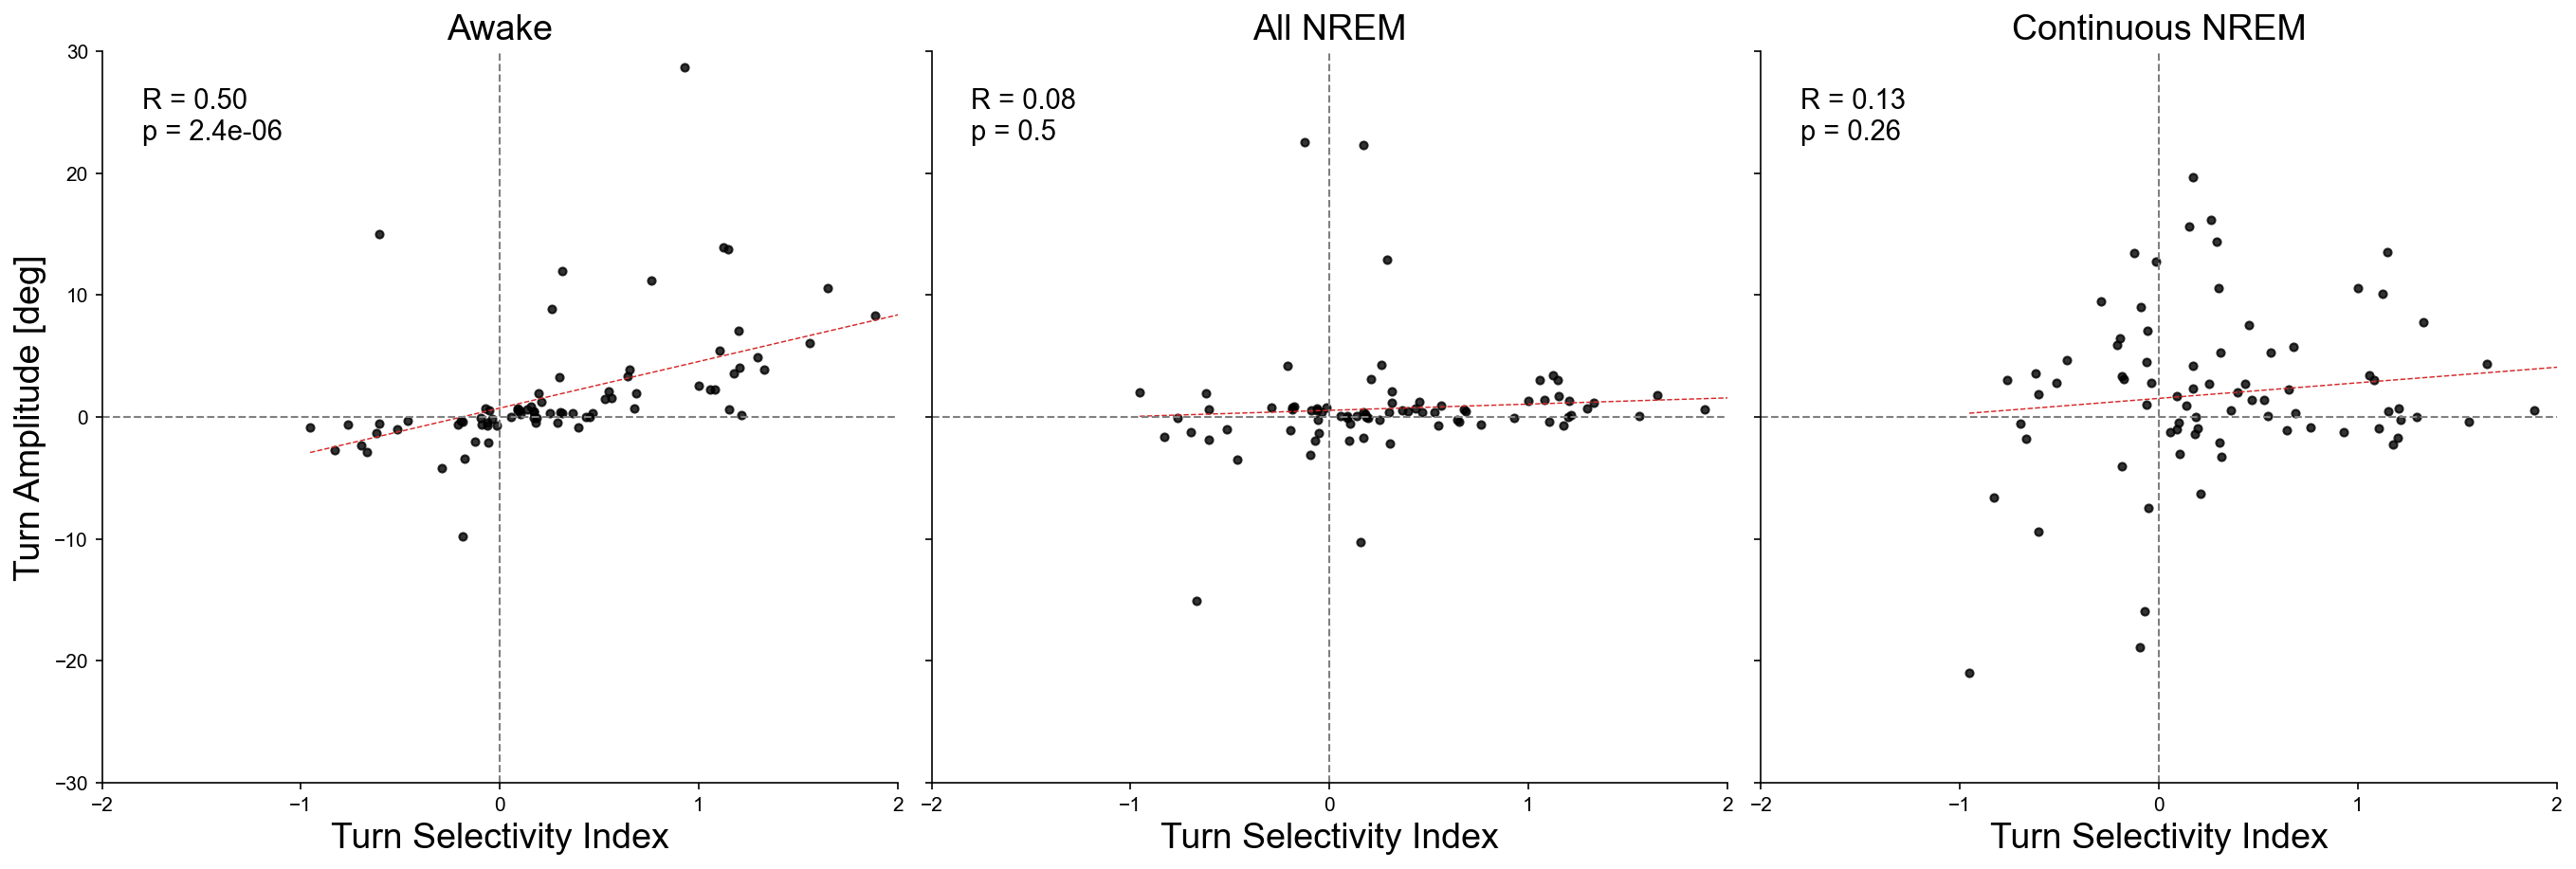

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True, constrained_layout=True)

plot_scatter_with_regression(axes[0], tsi, turn_amps_awake, 'Awake', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[1], tsi, turn_amps_nrem, 'All NREM', xlabel='Turn Selectivity Index')
plot_scatter_with_regression(axes[2], tsi, turn_amps_nrem_cont, 'Continuous NREM', xlabel='Turn Selectivity Index')


for ax in axes:
    ax.set_xlim((-2, 2))
    ax.set_ylim((-30, 30))
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig(save_dir / "turn_amplitude_tsi.png")